In [2]:
import time
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path
import schwabdev as sd
import time as tm
import zarr
import shutil
import os

import warnings

warnings.filterwarnings('ignore', message="The data type .* does not have a Zarr V3 specification.*")
warnings.filterwarnings('ignore', message="Consolidated metadata is currently not part in the Zarr format 3 specification.*")

from main_classes.DataManager import DataManager as DM
from utility.lib_apiManagment import create_client as CC

dm = DM()
zarr_store = xr.open_dataset(dm.hot_db_path)
zarr_store

<xarray.Dataset> Size: 11GB
Dimensions:  (day: 25, time: 288, ident: 5094, qVar: 36, fVar: 18)
Coordinates:
  * fVar     (fVar) <U28 2kB 'assetSubType' 'ssid' ... 'quote.closePrice'
  * day      (day) <U10 1kB '2025-09-14' '2025-09-15' ... '2025-10-14'
  * time     (time) <U5 6kB '00:00' '00:05' '00:10' ... '23:45' '23:50' '23:55'
  * qVar     (qVar) <U29 4kB 'reference.htbRate' ... 'quote.postMarketPercent...
  * ident    (ident) <U5 102kB 'A' 'AA' 'AACB' 'AACI' ... 'ZYBT' 'ZYME' 'ZYXI'
Data variables:
    5m       (day, time, ident, qVar) float64 11GB ...
    1d       (day, ident, fVar) float64 18MB ...

In [3]:
df = pd.read_csv('DT_2025-09-29_quote.mark.csv')

In [4]:
df

,time,A,AA,AACB,AACI,AAL,AAM,AAME,AAMI,AAOI,...,ZTEK,ZTS,ZUMZ,ZURA,ZVIA,ZVRA,ZWS,ZYBT,ZYME,ZYXI
0,00:00,123.39,32.71,10.18,10.40,11.31,10.52,2.90,48.94,25.77,...,0.8466,143.50,19.97,2.41,2.71,9.77,46.78,1.84,16.60,1.45
1,00:05,123.39,32.71,10.18,10.40,11.31,10.52,2.90,48.94,25.77,...,0.8466,143.50,19.97,2.41,2.71,9.77,46.78,1.84,16.60,1.45
2,00:10,123.39,32.71,10.18,10.40,11.31,10.52,2.90,48.94,25.77,...,0.8466,143.50,19.97,2.41,2.71,9.77,46.78,1.84,16.60,1.45
3,00:15,123.39,32.71,10.18,10.40,11.31,10.52,2.90,48.94,25.77,...,0.8466,143.50,19.97,2.41,2.71,9.77,46.78,1.84,16.60,1.45
4,00:20,123.39,32.71,10.18,10.40,11.31,10.52,2.90,48.94,25.77,...,0.8466,143.50,19.97,2.41,2.71,9.77,46.78,1.84,16.60,1.45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283,23:35,123.75,33.81,10.18,10.47,11.38,10.50,2.91,49.00,25.94,...,0.8415,143.06,19.83,3.24,2.73,9.60,46.89,2.07,17.23,1.47
284,23:40,123.75,33.81,10.18,10.47,11.38,10.50,2.91,49.00,25.94,...,0.8415,143.06,19.83,3.24,2.73,9.60,46.89,2.07,17.23,1.47
285,23:45,123.75,33.81,10.18,10.47,11.38,10.50,2.91,49.00,25.94,...,0.8415,143.06,19.83,3.24,2.73,9.60,46.89,2.07,17.23,1.47
286,23:50,123.75,33.81,10.18,10.47,11.38,10.50,2.91,49.00,25.94,...,0.8415,143.06,19.83,3.24,2.73,9.60,46.89,2.07,17.23,1.47


In [28]:
df_48 = df.iloc[48:241]
df_48 = df_48.drop('time', axis=1)
r = df_48.pct_change()
rtxm = r.sub(r.mean(axis=1), axis=0)

# For each stock, create pairs of consecutive returns
paired_list = []
for stock in rtxm.columns:
    stock_returns = rtxm[stock].values
    for i in range(len(stock_returns) - 1):
        paired_list.append({
            'rtxm_t': stock_returns[i],
            'rtxm_t+1': stock_returns[i + 1]
        })

result_df = pd.DataFrame(paired_list)

/tmp/ipykernel_207552/1203257646.py:3: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  r = df_48.pct_change()


Original rows: 971328
Rows after removing NaN: 966269
Rows after removing outliers: 966152


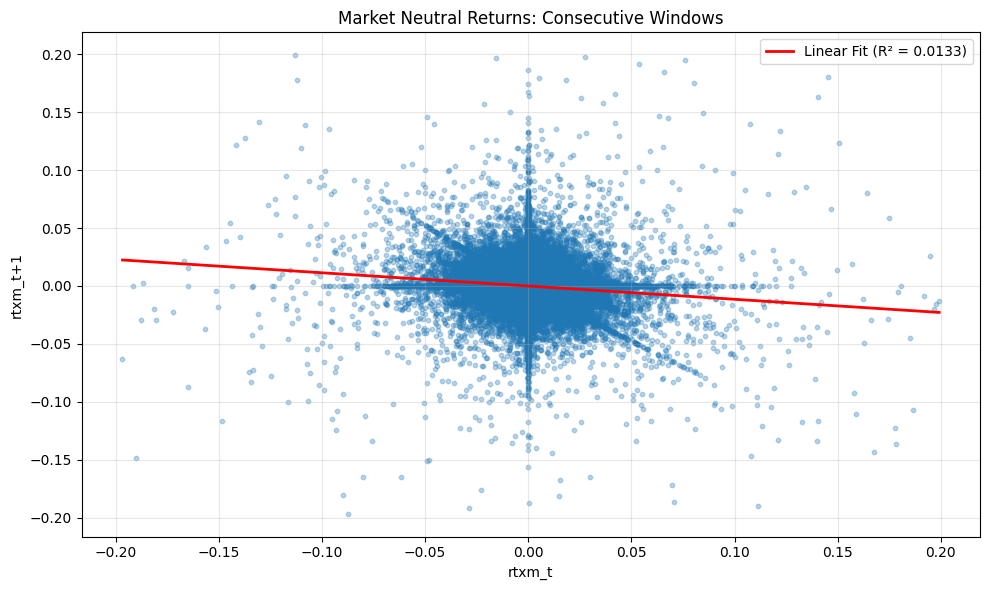


Regression Results:
Slope: -0.114390
Intercept: -0.000067
R-squared: 0.013269
P-value: 0.0


In [27]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

OUTLIER_MAX = 0.2

# Remove NaN values
clean_df = result_df.dropna()

# Remove outliers greater than 1 in absolute value
clean_df = clean_df[(np.abs(clean_df['rtxm_t']) <= OUTLIER_MAX) & (np.abs(clean_df['rtxm_t+1']) <= OUTLIER_MAX)]
#clean_df = clean_df[(np.abs(clean_df['rtxm_t']) <= OUTLIER_MAX)]


print(f"Original rows: {len(result_df)}")
print(f"Rows after removing NaN: {len(result_df.dropna())}")
print(f"Rows after removing outliers: {len(clean_df)}")

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(clean_df['rtxm_t'], clean_df['rtxm_t+1'], alpha=0.3, s=10)

# Calculate regression line
slope, intercept, r_value, p_value, std_err = stats.linregress(clean_df['rtxm_t'], clean_df['rtxm_t+1'])
line_x = np.array([clean_df['rtxm_t'].min(), clean_df['rtxm_t'].max()])
line_y = slope * line_x + intercept

# Plot regression line
plt.plot(line_x, line_y, 'r-', linewidth=2, label=f'Linear Fit (R² = {r_value**2:.4f})')

plt.xlabel('rtxm_t')
plt.ylabel('rtxm_t+1')
plt.title('Market Neutral Returns: Consecutive Windows')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print regression stats
print(f"\nRegression Results:")
print(f"Slope: {slope:.6f}")
print(f"Intercept: {intercept:.6f}")
print(f"R-squared: {r_value**2:.6f}")
print(f"P-value: {p_value}")

/tmp/ipykernel_207552/2397404123.py:3: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  r = df_104.pct_change()


Original rows: 364248
Rows after removing NaN: 359189
Rows after removing outliers: 359188


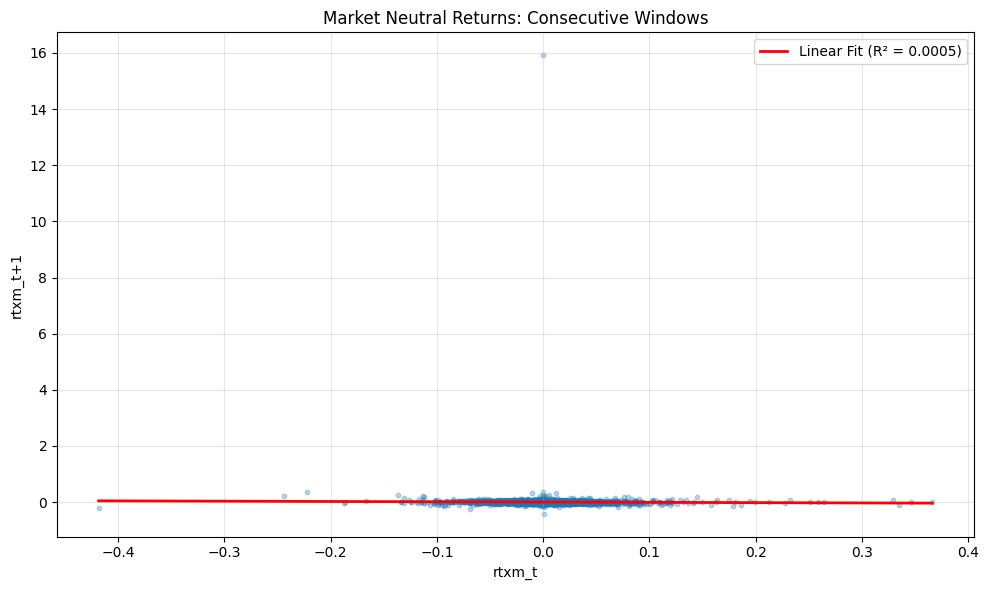


Regression Results:
Slope: -0.103497
Intercept: -0.000004
R-squared: 0.000465
P-value: 3.394458040968115e-38


In [43]:
df_104 = df.iloc[120:193]
df_104 = df_104.drop('time', axis=1)
r = df_104.pct_change()
rtxm = r.sub(r.mean(axis=1), axis=0)

# For each stock, create pairs of consecutive returns
paired_list = []
for stock in rtxm.columns:
    stock_returns = rtxm[stock].values
    for i in range(len(stock_returns) - 1):
        paired_list.append({
            'rtxm_t': stock_returns[i],
            'rtxm_t+1': stock_returns[i + 1]
        })

result_df = pd.DataFrame(paired_list)
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

OUTLIER_MAX = 1
OUTLIER_MIN = 0.1

# Remove NaN values
clean_df = result_df.dropna()

# Remove outliers greater than 1 in absolute value
#clean_df = clean_df[(np.abs(clean_df['rtxm_t']) <= OUTLIER_MAX) & (np.abs(clean_df['rtxm_t+1']) <= OUTLIER_MAX)]
clean_df = clean_df[(np.abs(clean_df['rtxm_t']) <= OUTLIER_MAX)]
#clean_df = clean_df[(np.abs(clean_df['rtxm_t']) <= OUTLIER_MAX) & (np.abs(clean_df['rtxm_t+1']) <= OUTLIER_MAX) & (np.abs(clean_df['rtxm_t']) >= OUTLIER_MIN) & (np.abs(clean_df['rtxm_t+1']) >= OUTLIER_MIN)]
#clean_df = clean_df[(np.abs(clean_df['rtxm_t']) <= OUTLIER_MAX) & (np.abs(clean_df['rtxm_t']) >= OUTLIER_MIN)]

print(f"Original rows: {len(result_df)}")
print(f"Rows after removing NaN: {len(result_df.dropna())}")
print(f"Rows after removing outliers: {len(clean_df)}")

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(clean_df['rtxm_t'], clean_df['rtxm_t+1'], alpha=0.3, s=10)

# Calculate regression line
slope, intercept, r_value, p_value, std_err = stats.linregress(clean_df['rtxm_t'], clean_df['rtxm_t+1'])
line_x = np.array([clean_df['rtxm_t'].min(), clean_df['rtxm_t'].max()])
line_y = slope * line_x + intercept

# Plot regression line
plt.plot(line_x, line_y, 'r-', linewidth=2, label=f'Linear Fit (R² = {r_value**2:.4f})')

plt.xlabel('rtxm_t')
plt.ylabel('rtxm_t+1')
plt.title('Market Neutral Returns: Consecutive Windows')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print regression stats
print(f"\nRegression Results:")
print(f"Slope: {slope:.6f}")
print(f"Intercept: {intercept:.6f}")
print(f"R-squared: {r_value**2:.6f}")
print(f"P-value: {p_value}")